In [95]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [96]:
tau_loss = 200
tau_in = 1
tau_out = 1

eta_in = 0.95
eta_out = 0.95

delta_t = 1 # h

A = -1/tau_loss
B = np.array([eta_in, -1/eta_out])

In [97]:
A_d = np.exp(A*delta_t)
B_d = np.dot(B,scipy.integrate.quad(lambda tau: np.exp(A*tau),0,delta_t)[0])
print(f"A_d: {A_d}\nB_d: {B_d}")

A_d: 0.9950124791926823
B_d: [ 0.94762895 -1.05000438]


In [98]:
A_dE = (1+A*delta_t)
B_dE = B*delta_t

print(f"delta A/A: {(A_d-A_dE)/A_d}\ndelta B/B: {[(B_d-B_dE)[0]/B_d[0], (B_d-B_dE)[1]/B_d[1]]}")

delta A/A: 1.254174489595286e-05
delta B/B: [-0.0025020833324652324, -0.002502083332465266]


delta A/A: 1.254174489595286e-05
delta B/B: [-0.0025020833324652324, -0.002502083332465266]
delta A/A: 0.0012924584427772162
delta B/B: [-0.025208324653294537, -0.025208324653294357]


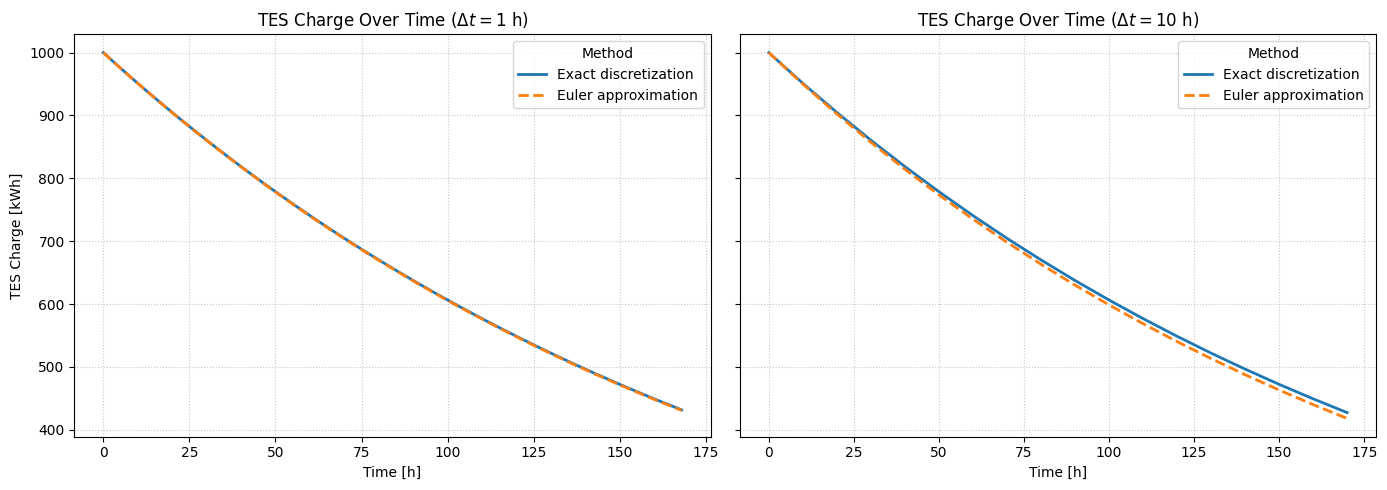

In [99]:
# Analytic solution

def simulate_decay(delta_t: float, t_f: int = 168, x_0: float = 1000):
    ts = np.arange(0, t_f + delta_t, delta_t)
    A_d = np.exp(A * delta_t)
    B_d = np.dot(B, scipy.integrate.quad(lambda tau: np.exp(A * tau), 0, delta_t)[0])
    A_dE = 1 + A * delta_t
    B_dE = B * delta_t
    print(f"delta A/A: {(A_d-A_dE)/A_d}\ndelta B/B: {[(B_d-B_dE)[0]/B_d[0], (B_d-B_dE)[1]/B_d[1]]}")

    xs = [x_0]
    xsE = [x_0]
    for _ in ts[1:]:
        xs.append(A_d * xs[-1])
        xsE.append(A_dE * xsE[-1])

    return ts, np.array(xs), np.array(xsE), A_d, B_d, A_dE, B_dE

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, delta_t in zip(axes, [1, 10]):
    ts, xs, xsE, _, _, _, _ = simulate_decay(delta_t)
    axis.plot(ts, xs, label="Exact discretization", linewidth=2)
    axis.plot(ts, xsE, label="Euler approximation", linewidth=2, linestyle="--")
    axis.set_title(f"TES Charge Over Time ($\\Delta t = {delta_t}$ h)")
    axis.set_xlabel("Time [h]")
    axis.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.7)
    axis.legend(title="Method")

axes[0].set_ylabel("TES Charge [kWh]")
fig.tight_layout()

plt.savefig("discretization_comparison.png", dpi=300)